In [ ]:
import kagglehub
path = kagglehub.dataset_download("sriharshabsprasad/movielens-dataset-100k-ratings")

100%|██████████| 971k/971k [00:00<00:00, 1.92MB/s]

Extracting files...


In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [ ]:
data_path = os.path.join(path, "ml-latest-small")

print(os.listdir(data_path))

['README.txt', 'ratings.csv', 'links.csv', 'tags.csv', 'movies.csv']


In [ ]:
ratings_df = pd.read_csv(os.path.join(data_path, "ratings.csv"))
movies_df = pd.read_csv(os.path.join(data_path, "movies.csv"))

In [ ]:
ratings_df.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [ ]:
movies_df.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [ ]:
combined_df = ratings_df.merge(
    movies_df,
    on="movieId",
    how="left"
)

combined_df.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [ ]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
 4   title      100836 non-null  object 
 5   genres     100836 non-null  object 
dtypes: float64(1), int64(3), object(2)
memory usage: 4.6+ MB


In [ ]:
combined_df.describe()

,userId,movieId,rating,timestamp
count,100836.000000,100836.000000,100836.000000,1.008360e+05
mean,326.127564,19435.295718,3.501557,1.205946e+09
std,182.618491,35530.987199,1.042529,2.162610e+08
min,1.000000,1.000000,0.500000,8.281246e+08
25%,177.000000,1199.000000,3.000000,1.019124e+09
50%,325.000000,2991.000000,3.500000,1.186087e+09
75%,477.000000,8122.000000,4.000000,1.435994e+09
max,610.000000,193609.000000,5.000000,1.537799e+09


In [ ]:
combined_df.isnull().sum()

,0
userId,0
movieId,0
rating,0
timestamp,0
title,0
genres,0


In [ ]:
combined_df.duplicated().sum()

np.int64(0)

In [ ]:
combined_df["rating"].value_counts().sort_index()

,count
rating,
0.5,1370
1.0,2811
1.5,1791
2.0,7551
2.5,5550
3.0,20047
3.5,13136
4.0,26818
4.5,8551


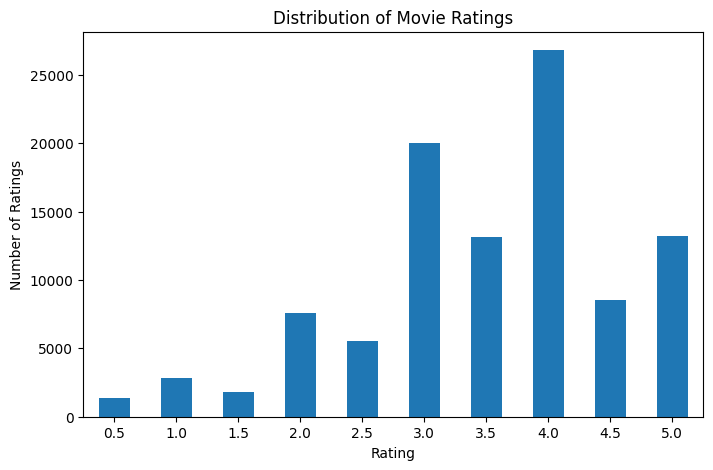

In [ ]:
plt.figure(figsize=(8, 5))

combined_df["rating"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.title("Distribution of Movie Ratings")
plt.xticks(rotation=0)
plt.show()

In [ ]:
num_users = combined_df["userId"].nunique()
num_movies = combined_df["movieId"].nunique()
num_ratings = len(combined_df)

print("Number of users:", num_users)
print("Number of movies:", num_movies)
print("Number of ratings:", num_ratings)

Number of users: 610
Number of movies: 9724
Number of ratings: 100836


In [ ]:
total_possible_ratings = num_users * num_movies

sparsity = 1 - (num_ratings / total_possible_ratings)

print(f"Matrix sparsity: {sparsity:.2%}")

Matrix sparsity: 98.30%


In [ ]:
movie_rating_counts = (
    combined_df.groupby(["movieId", "title"])
    .size()
    .sort_values(ascending=False)
)

movie_rating_counts.head(10)

,,0
movieId,title,
356,Forrest Gump (1994),329
318,"Shawshank Redemption, The (1994)",317
296,Pulp Fiction (1994),307
593,"Silence of the Lambs, The (1991)",279
2571,"Matrix, The (1999)",278
260,Star Wars: Episode IV - A New Hope (1977),251
480,Jurassic Park (1993),238
110,Braveheart (1995),237
589,Terminator 2: Judgment Day (1991),224


In [ ]:
user_rating_counts = (
    combined_df.groupby("userId")
    .size()
    .sort_values(ascending=False)
)

user_rating_counts.head(10)

,0
userId,
414,2698
599,2478
474,2108
448,1864
274,1346
610,1302
68,1260
380,1218
606,1115


In [ ]:
movie_avg_ratings = (
    combined_df.groupby(["movieId", "title"])["rating"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

movie_avg_ratings.head(10)

,,mean,count
movieId,title,,
99,Heidi Fleiss: Hollywood Madam (1995),5.0,2
64501,Che: Part Two (2008),5.0,1
1349,Vampire in Venice (Nosferatu a Venezia) (Nosferatu in Venice) (1986),5.0,1
86721,Idiots and Angels (2008),5.0,1
86668,Louis Theroux: Law & Disorder (2008),5.0,1
7815,True Stories (1986),5.0,1
2972,Red Sorghum (Hong gao liang) (1987),5.0,1
2969,"Man and a Woman, A (Un homme et une femme) (1966)",5.0,1
163925,"Wings, Legs and Tails (1986)",5.0,1


In [ ]:
model_df = combined_df[["userId", "movieId", "rating"]].copy()

model_df.head()

,userId,movieId,rating
0,1,1,4.0
1,1,3,4.0
2,1,6,4.0
3,1,47,5.0
4,1,50,5.0


In [ ]:
train_df, test_df = train_test_split(
    model_df,
    test_size=0.2,
    random_state=42
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Testing samples:", len(test_df))

Training samples: 64534
Validation samples: 16134
Testing samples: 20168


In [ ]:
user_ids = model_df["userId"].unique()

user_to_idx = {
    user_id: idx
    for idx, user_id in enumerate(user_ids)
}

train_df["user_idx"] = train_df["userId"].map(user_to_idx)
val_df["user_idx"] = val_df["userId"].map(user_to_idx)
test_df["user_idx"] = test_df["userId"].map(user_to_idx)

In [ ]:
movie_ids = model_df["movieId"].unique()

movie_to_idx = {
    movie_id: idx
    for idx, movie_id in enumerate(movie_ids)
}

train_df["movie_idx"] = train_df["movieId"].map(movie_to_idx)
val_df["movie_idx"] = val_df["movieId"].map(movie_to_idx)
test_df["movie_idx"] = test_df["movieId"].map(movie_to_idx)

In [ ]:
num_users = len(user_to_idx)
num_movies = len(movie_to_idx)

print("Number of users:", num_users)
print("Number of movies:", num_movies)

print(train_df.head())

Number of users: 610
Number of movies: 9724
       userId  movieId  rating  user_idx  movie_idx
20287     133      474     3.0       132        474
48553     313     4518     4.0       312        278
97573     606     1227     4.0       605       1163
31892     219     7090     4.5       218       2250
62892     414     1701     2.0       413       7388


In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cuda


In [ ]:
class MovieRatingDataset(Dataset):

    def __init__(self, X, y):
        self.users = torch.tensor(
            X["user_idx"].values,
            dtype=torch.long
        )

        self.movies = torch.tensor(
            X["movie_idx"].values,
            dtype=torch.long
        )

        self.ratings = torch.tensor(
            y.values,
            dtype=torch.float32
        )

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return (
            self.users[idx],
            self.movies[idx],
            self.ratings[idx]
        )

In [ ]:
X_train = train_df[["user_idx", "movie_idx"]]
y_train = train_df["rating"]

X_val = val_df[["user_idx", "movie_idx"]]
y_val = val_df["rating"]

X_test = test_df[["user_idx", "movie_idx"]]
y_test = test_df["rating"]

In [ ]:
train_dataset = MovieRatingDataset(X_train, y_train)
val_dataset = MovieRatingDataset(X_val, y_val)
test_dataset = MovieRatingDataset(X_test, y_test)

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=256,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False
)

In [ ]:
class NCF(nn.Module):

    def __init__(
        self,
        num_users,
        num_movies,
        embedding_dim=32
    ):
        super().__init__()

        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.movie_embedding = nn.Embedding(num_movies, embedding_dim)

        self.user_bias = nn.Embedding(num_users, 1)
        self.movie_bias = nn.Embedding(num_movies, 1)

        self.emb_dropout = nn.Dropout(0.3)

        self.mlp = nn.Sequential(
            nn.Linear(embedding_dim * 2, 128),
            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(16, 1)
        )

        nn.init.normal_(self.user_embedding.weight, std=0.05)
        nn.init.normal_(self.movie_embedding.weight, std=0.05)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.movie_bias.weight)
        nn.init.constant_(self.mlp[12].bias, 0.69)

    def forward(self, users, movies):

        user_vector = self.emb_dropout(self.user_embedding(users))
        movie_vector = self.emb_dropout(self.movie_embedding(movies))

        x = torch.cat([user_vector, movie_vector], dim=1)
        mlp_out = self.mlp(x).squeeze(-1)

        dot = (user_vector * movie_vector).sum(dim=1)
        u_b = self.user_bias(users).squeeze(-1)
        m_b = self.movie_bias(movies).squeeze(-1)

        raw = mlp_out + dot + u_b + m_b
        return 0.5 + 4.5 * torch.sigmoid(raw)

In [ ]:
model = NCF(
    num_users=num_users,
    num_movies=num_movies,
    embedding_dim=16
).to(device)

print(model)

NCF(
  (user_embedding): Embedding(610, 16)
  (movie_embedding): Embedding(9724, 16)
  (user_bias): Embedding(610, 1)
  (movie_bias): Embedding(9724, 1)
  (emb_dropout): Dropout(p=0.3, inplace=False)
  (mlp): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=32, out_features=16, bias=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=16, out_features=1, bias=True)
  )
)


In [ ]:
criterion = nn.MSELoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-2
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=1
)

In [ ]:
patience = 5

best_val_loss = float("inf")
patience_counter = 0

best_model_state = None

In [ ]:
epochs = 100

train_losses = []
val_losses = []

best_val_loss = float("inf")
patience_counter = 0
best_model_state = None

for epoch in range(epochs):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    total_train_loss = 0

    for users, movies, ratings in train_loader:

        users = users.to(device)
        movies = movies.to(device)
        ratings = ratings.to(device)

        optimizer.zero_grad()

        predictions = model(users, movies)

        loss = criterion(
            predictions,
            ratings
        )

        loss.backward()

        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = (
        total_train_loss / len(train_loader)
    )


    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    total_val_loss = 0

    with torch.no_grad():

        for users, movies, ratings in val_loader:

            users = users.to(device)
            movies = movies.to(device)
            ratings = ratings.to(device)

            predictions = model(
                users,
                movies
            )

            loss = criterion(
                predictions,
                ratings
            )

            total_val_loss += loss.item()

    avg_val_loss = (
        total_val_loss / len(val_loader)
    )


    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    scheduler.step(avg_val_loss)


    print(
        f"Epoch {epoch + 1:02d}/{epochs} "
        f"| Train Loss: {avg_train_loss:.4f} "
        f"| Val Loss: {avg_val_loss:.4f}"
    )


    # -------------------------
    # Early Stopping
    # -------------------------

    if avg_val_loss < best_val_loss:

        best_val_loss = avg_val_loss
        patience_counter = 0

        # Save best model
        best_model_state = {
            key: value.cpu().clone()
            for key, value in model.state_dict().items()
        }

    else:

        patience_counter += 1

        print(
            f"No improvement "
            f"({patience_counter}/{patience})"
        )

        if patience_counter >= patience:

            print("Early stopping triggered.")

            break

Epoch 01/100 | Train Loss: 0.9996 | Val Loss: 0.8223
Epoch 02/100 | Train Loss: 0.7999 | Val Loss: 0.7525
Epoch 03/100 | Train Loss: 0.7295 | Val Loss: 0.7372
Epoch 04/100 | Train Loss: 0.6901 | Val Loss: 0.7354
Epoch 05/100 | Train Loss: 0.6629 | Val Loss: 0.7374
No improvement (1/5)
Epoch 06/100 | Train Loss: 0.6402 | Val Loss: 0.7375
No improvement (2/5)
Epoch 07/100 | Train Loss: 0.6175 | Val Loss: 0.7396
No improvement (3/5)
Epoch 08/100 | Train Loss: 0.6077 | Val Loss: 0.7392
No improvement (4/5)
Epoch 09/100 | Train Loss: 0.5974 | Val Loss: 0.7437
No improvement (5/5)
Early stopping triggered.


In [ ]:
model.load_state_dict(best_model_state)

model.eval()

predictions = []
actuals = []

with torch.no_grad():
    for users, movies, ratings in test_loader:
        users = users.to(device)
        movies = movies.to(device)

        outputs = model(users, movies)

        predictions.extend(outputs.cpu().numpy())
        actuals.extend(ratings.numpy())

predictions = np.array(predictions)
actuals = np.array(actuals)

mae = np.mean(np.abs(predictions - actuals))
rmse = np.sqrt(np.mean((predictions - actuals) ** 2))

print("Test MAE :", mae)
print("Test RMSE:", rmse)

Test MAE : 0.66977173
Test RMSE: 0.8787987


In [ ]:
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "num_users": num_users,
        "num_movies": num_movies,
        "embedding_dim": 16,
    },
    "ncf_model.pth"
)

In [ ]:
# Select a user for recommendation
user_id = 1

print("Selected User:", user_id)

Selected User: 1


In [ ]:
# Movies already rated by the user
rated_movies = set(
    ratings_df.loc[
        ratings_df["userId"] == user_id,
        "movieId"
    ]
)

print("Number of rated movies:", len(rated_movies))

Number of rated movies: 232


In [ ]:
all_movie_ids = movies_df["movieId"].unique()

print("Total movies:", len(all_movie_ids))

Total movies: 9742


In [ ]:
unseen_movie_ids = [
    movie_id
    for movie_id in all_movie_ids
    if movie_id not in rated_movies
    and movie_id in movie_to_idx
]

print("Unseen movies available to NCF:", len(unseen_movie_ids))

Unseen movies available to NCF: 9492


In [ ]:
user_idx = user_to_idx[user_id]

movie_indices = [
    movie_to_idx[movie_id]
    for movie_id in unseen_movie_ids
]

In [ ]:
user_tensor = torch.tensor(
    [user_idx] * len(movie_indices),
    dtype=torch.long
).to(device)

movie_tensor = torch.tensor(
    movie_indices,
    dtype=torch.long
).to(device)

In [ ]:
model.eval()

with torch.no_grad():
    predicted_ratings = model(
        user_tensor,
        movie_tensor
    )

predicted_ratings = predicted_ratings.cpu().numpy()

In [ ]:
recommendation_df = pd.DataFrame({
    "movieId": unseen_movie_ids,
    "predicted_rating": predicted_ratings
})

# Sort using the raw model predictions
recommendation_df = recommendation_df.sort_values(
    by="predicted_rating",
    ascending=False
).reset_index(drop=True)

In [ ]:
recommendation_df["display_rating"] = (
    recommendation_df["predicted_rating"].clip(0.5, 5.0)
)

In [ ]:
top_k = 10

top_recommendations = recommendation_df.head(top_k).copy()

In [ ]:
top_recommendations = top_recommendations.merge(
    movies_df[["movieId", "title", "genres"]],
    on="movieId",
    how="left"
)

In [ ]:
top_recommendations[
    ["movieId", "title", "genres", "display_rating"]
]

,movieId,title,genres,display_rating
0,6460,"Trial, The (Procès, Le) (1962)",Drama,5.000000
1,1104,"Streetcar Named Desire, A (1951)",Drama,4.992626
2,92535,Louis C.K.: Live at the Beacon Theater (2011),Comedy,4.982740
3,1217,Ran (1985),Drama|War,4.981642
4,3741,Badlands (1973),Crime|Drama|Thriller,4.960025
5,3347,Never Cry Wolf (1983),Adventure|Drama,4.958574
6,1041,Secrets & Lies (1996),Drama,4.956474
7,1178,Paths of Glory (1957),Drama|War,4.952507
8,158398,World of Glory (1991),Comedy,4.939951
9,2360,"Celebration, The (Festen) (1998)",Drama,4.933751


In [ ]:
import pickle

recommendation_data = {
    "user_to_idx": user_to_idx,
    "movie_to_idx": movie_to_idx,
    "movies_df": movies_df,
    "ratings_df": ratings_df
}

with open("recommendation_data.pkl", "wb") as f:
    pickle.dump(recommendation_data, f)

print("Recommendation data saved successfully.")

Recommendation data saved successfully.
